Protein type: seen
Number of targets: 85
Bin edges: [  0.   1.  10. 100. 117.]
Valid cols: ['0-1', '1-10', '10-100', '100-117']
Saved figure to: /home/user-home/fanzhehuan/myprojects/MolGenBench/FigShow_new/final_plot/output/TAScore/target_aware_score_TAScore_seen_protein_with_values_with_legend.svg


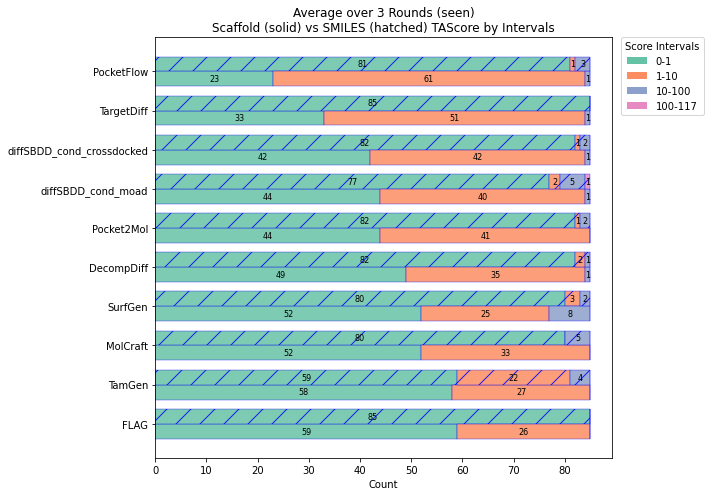

Protein type: seen
Number of targets: 85
Bin edges: [  0.   1.  10. 100. 117.]
Valid cols: ['0-1', '1-10', '10-100', '100-117']
Saved figure to: /home/user-home/fanzhehuan/myprojects/MolGenBench/FigShow_new/final_plot/output/TAScore/target_aware_score_TAScore_seen_protein_with_legend.svg


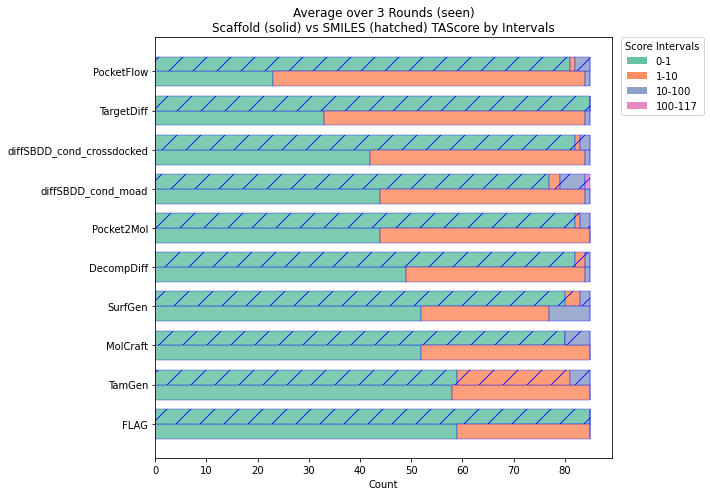

Protein type: unseen
Number of targets: 35
Bin edges: [  0.   1.  10. 100. 105.]
Valid cols: ['0-1', '1-10', '10-100', '100-105']
Saved figure to: /home/user-home/fanzhehuan/myprojects/MolGenBench/FigShow_new/final_plot/output/TAScore/target_aware_score_TAScore_unseen_protein_with_values_with_legend.svg


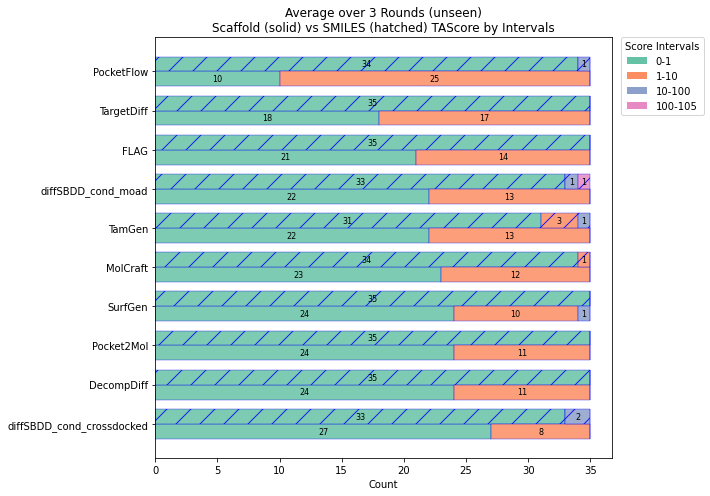

Protein type: unseen
Number of targets: 35
Bin edges: [  0.   1.  10. 100. 105.]
Valid cols: ['0-1', '1-10', '10-100', '100-105']
Saved figure to: /home/user-home/fanzhehuan/myprojects/MolGenBench/FigShow_new/final_plot/output/TAScore/target_aware_score_TAScore_unseen_protein_with_legend.svg


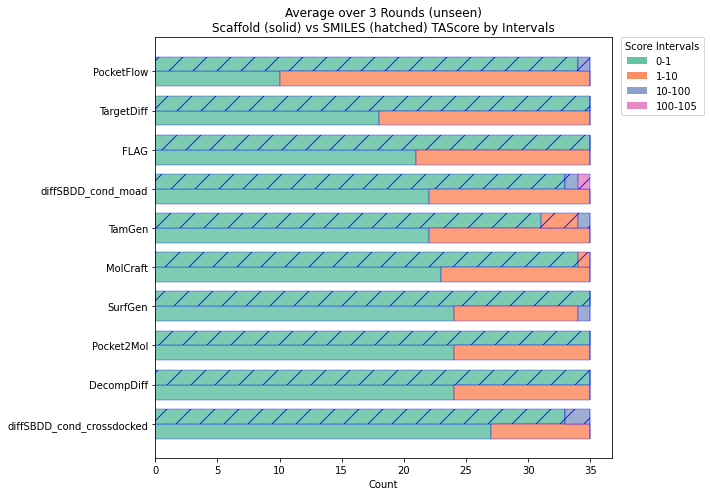

In [ ]:
import os
import sys
code_path = "/home/user-home/fanzhehuan/myprojects/MolGenBench/"
sys.path.append(code_path)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sup_info.utils import uniprot_in_trainset

# ==================== 配置部分 ====================
TASK_LIST_DENOVO = [
    'MolCraft_generated_molecules',
    'DecompDiff_generated_molecules',
    'FLAG_generated_molecules',
    'PocketFlow_generated_molecules',
    'SurfGen_generated_molecules',
    'TargetDiff_generated_molecules',
    'TamGen_generated_molecules',
    "Pocket2Mol_generated_molecules",
    "diffSBDD_cond_crossdocked_generated_molecules",
    "diffSBDD_cond_moad_generated_molecules"
]

DENOVO_NAME_MAPPING = {
    "MolCraft_generated_molecules": "MolCraft",
    "DecompDiff_generated_molecules": "DecompDiff",
    "FLAG_generated_molecules": "FLAG",
    "PocketFlow_generated_molecules": "PocketFlow",
    "SurfGen_generated_molecules": "SurfGen",
    "TargetDiff_generated_molecules": "TargetDiff",
    "TamGen_generated_molecules": "TamGen",
    "Pocket2Mol_generated_molecules": "Pocket2Mol",
    "diffSBDD_cond_crossdocked_generated_molecules": "diffSBDD_cond_crossdocked",
    "diffSBDD_cond_moad_generated_molecules": "diffSBDD_cond_moad",
}

# 3个Round的路径
results_base_path = "/home/user-home/fanzhehuan/myprojects/MolGenBench/paper_results"
round_list = ["Round1", "Round2", "Round3"]
output_path = "/home/user-home/fanzhehuan/myprojects/MolGenBench/FigShow/final_plot/output/TAScore"

# 确保输出目录存在
os.makedirs(output_path, exist_ok=True)

# ==================== 数据读取（3个Round） ====================
results_df = []
for round_name in round_list:
    results_path = os.path.join(results_base_path, round_name, "De_novo_Results")
    for task in TASK_LIST_DENOVO:
        file = os.path.join(results_path, task, "hitrediscovery_detail.csv")
        if os.path.exists(file):
            df = pd.read_csv(file)
            df["ModelName"] = DENOVO_NAME_MAPPING[task]
            df["Round"] = round_name
            results_df.append(df)
        else:
            print(f"Warning: File not found - {file}")

result_df = pd.concat(results_df, ignore_index=True)

# ...existing code...

# ==================== 绘图函数 ====================
def plot_TAScore_counts(
    result_df,
    trainset_uniprots=None,
    protein_type='all',
    show_values=True,
    show_legend=True,
    save_dir='.',
    image_name='TAScore'):
    """
    绘制 smiles_TAScore 和 scaffold_TAScore 的分箱堆叠条形图
    
    Parameters:
    -----------
    result_df : DataFrame with columns: uniprot, ModelName, Round, smiles_TAScore, scaffold_TAScore
    trainset_uniprots : set or dict keys, uniprots in training set (for seen/unseen filtering)
    protein_type : 'all', 'seen', 'unseen'
    show_values : whether to show count values on bars
    show_legend : whether to show legend
    save_dir : output directory
    image_name : base name for output file
    """
    
    _df = result_df.copy()
    
    # 过滤 target
    if protein_type == 'all':
        image_name += '_all_protein'
    elif protein_type == 'seen':
        image_name += '_seen_protein'
        if trainset_uniprots is not None:
            _df = _df[_df['uniprot'].isin(trainset_uniprots)]
    elif protein_type == 'unseen':
        image_name += '_unseen_protein'
        if trainset_uniprots is not None:
            _df = _df[~_df['uniprot'].isin(trainset_uniprots)]
    
    print(f'Protein type: {protein_type}')
    print(f'Number of targets: {len(_df["uniprot"].unique())}')
    
    # 按 (ModelName, uniprot) 平均三个 round
    _avg_df = (_df
               .groupby(['ModelName', 'uniprot'])[['scaffold_TAScore', 'smiles_TAScore']]
               .mean()
               .reset_index())
    
    _df_scores = _avg_df[['ModelName', 'uniprot', 'scaffold_TAScore', 'smiles_TAScore']].copy()
    
    # 动态分箱
    _edges_base = [0.0, 1.0, 10.0, 100.0]
    _upper = float(np.nanmax([
        _df_scores['scaffold_TAScore'].max(),
        _df_scores['smiles_TAScore'].max()
    ]))
    if _upper <= _edges_base[-1]:
        _upper = _edges_base[-1] + 1.0
    _upper_int = int(np.ceil(_upper))
    _bin_edges = np.array(_edges_base + [_upper_int], dtype=float)
    valid_cols = [f"{int(_bin_edges[i])}-{int(_bin_edges[i+1])}" for i in range(len(_bin_edges) - 1)]
    
    print('Bin edges:', _bin_edges)
    print('Valid cols:', valid_cols)
    
    # 分箱
    _cats_scf = pd.cut(_df_scores['scaffold_TAScore'],
                       bins=_bin_edges, labels=valid_cols, right=False, include_lowest=True)
    _cats_smi = pd.cut(_df_scores['smiles_TAScore'],
                       bins=_bin_edges, labels=valid_cols, right=False, include_lowest=True)
    
    # 统计计数
    _counts_scf = _df_scores.groupby(['ModelName', _cats_scf]).size().unstack(fill_value=0)
    _counts_smi = _df_scores.groupby(['ModelName', _cats_smi]).size().unstack(fill_value=0)
    
    all_targets_num = len(_avg_df['uniprot'].unique())
    
    # 补全缺失列
    for _lab in valid_cols:
        if _lab not in _counts_scf.columns:
            _counts_scf[_lab] = 0
        if _lab not in _counts_smi.columns:
            _counts_smi[_lab] = 0
    
    # 补充缺失的 target 到 0-1 桶
    if '0-1' in _counts_scf.columns:
        _counts_scf['0-1'] += (all_targets_num - _counts_scf.sum(axis=1)).clip(lower=0)
    if '0-1' in _counts_smi.columns:
        _counts_smi['0-1'] += (all_targets_num - _counts_smi.sum(axis=1)).clip(lower=0)
    
    # 只保留并按列顺序
    _counts_scf = _counts_scf[valid_cols]
    _counts_smi = _counts_smi[valid_cols]
    
    pivot_scf_plot = _counts_scf.copy()
    pivot_smi_plot = _counts_smi.copy()
    
    # 排序依据：Scaffold 的 0-1 bin 计数降序
    order = pivot_scf_plot.sort_values(by=valid_cols[0], ascending=False).index.tolist()
    pivot_scf_sorted = pivot_scf_plot.loc[order]
    pivot_smi_sorted = pivot_smi_plot.loc[order]
    
    models = order
    n_models = len(models)
    y = np.arange(n_models)
    h = 0.38
    
    colors = sns.color_palette("Set2", n_colors=len(valid_cols))
    fig, ax = plt.subplots(figsize=(10, 0.6 * n_models + 1))
    
    bscf = np.zeros(n_models, dtype=float)
    bsmi = np.zeros(n_models, dtype=float)
    
    # 真实每个模型 target 总数
    model_target_counts = pivot_scf_sorted.sum(axis=1)
    xmax = model_target_counts.max() * 1.05
    
    # 堆积条形
    for i, lab in enumerate(valid_cols):
        vals_scf = pivot_scf_sorted[lab].values.astype(float)
        vals_smi = pivot_smi_sorted[lab].values.astype(float)
        
        ax.barh(y - h / 2, vals_scf, left=bscf, height=h,
                color=colors[i], alpha=0.85, edgecolor='blue', linewidth=0.4)
        ax.barh(y + h / 2, vals_smi, left=bsmi, height=h,
                color=colors[i], alpha=0.85, hatch='/', edgecolor='blue', linewidth=0.4)
        
        if show_values:
            centers_scf = bscf + vals_scf / 2
            centers_smi = bsmi + vals_smi / 2
            for r_idx, v in enumerate(vals_scf):
                if v > 0:
                    ax.text(centers_scf[r_idx], y[r_idx] - h / 2, f"{int(v)}",
                            ha='center', va='center', fontsize=8, color='black')
            for r_idx, v in enumerate(vals_smi):
                if v > 0:
                    ax.text(centers_smi[r_idx], y[r_idx] + h / 2, f"{int(v)}",
                            ha='center', va='center', fontsize=8, color='black')
        
        bscf += vals_scf
        bsmi += vals_smi
    
    ax.set_xlim(0, xmax)
    ax.set_yticks(y)
    ax.set_yticklabels(models)
    ax.set_xlabel('Count')
    ax.set_title(f'Average over 3 Rounds ({protein_type})\nScaffold (solid) vs SMILES (hatched) TAScore by Intervals')
    
    if show_legend:
        interval_handles = [Patch(facecolor=colors[i], label=lab) for i, lab in enumerate(valid_cols)]
        ax.legend(handles=interval_handles, title='Score Intervals',
                  loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0.)
    
    fig.tight_layout()
    
    # 构建文件名后缀
    suffix = ''
    if show_values:
        suffix += '_with_values'
    if show_legend:
        suffix += '_with_legend'
    if not show_values and not show_legend:
        suffix += '_clean'
    
    out_fig = os.path.join(save_dir, f'target_aware_score_{image_name}{suffix}.svg')
    plt.savefig(out_fig, bbox_inches='tight', dpi=600, format='svg')
    print(f'Saved figure to: {out_fig}')
    
    if protein_type == 'all' and show_values and show_legend:
        out_csv = os.path.join(save_dir, f'target_aware_score_{image_name}{suffix}.csv')
        _df_scores.to_csv(out_csv, index=False)
        print(f'Saved CSV to: {out_csv}')
    
    plt.show()
    
    return pivot_scf_plot, pivot_smi_plot, _df_scores


# ==================== 执行绘图 ====================
# 获取训练集中的 uniprot (如果需要 seen/unseen 过滤)
trainset_uniprots = set(uniprot_in_trainset.keys()) if hasattr(uniprot_in_trainset, 'keys') else set(uniprot_in_trainset)

# 遍历所有蛋白质类型和两种显示模式
for protein_type in ['seen', 'unseen']:
    # 版本1: 带 legend 和 text
    pivot_scf, pivot_smi, df_scores = plot_TAScore_counts(
        result_df,
        trainset_uniprots=trainset_uniprots,
        protein_type=protein_type,
        show_values=True,
        show_legend=True,
        save_dir=output_path,
        image_name='TAScore'
    )
    
    # 版本2: 不带 legend 和 text (clean version)
    plot_TAScore_counts(
        result_df,
        trainset_uniprots=trainset_uniprots,
        protein_type=protein_type,
        show_values=False,
        show_legend=True,
        save_dir=output_path,
        image_name='TAScore'
    )

Protein type: seen
Number of targets: 85
Bin edges: [  0.   1.  10. 100. 117.]
Valid cols: ['0-1', '1-10', '10-100', '100-117']
Saved figure to: /home/user-home/fanzhehuan/myprojects/MolGenBench/FigShow_new/final_plot/output/TAScore/target_aware_score_TAScore_seen_protein_proportion_with_values_with_legend.svg


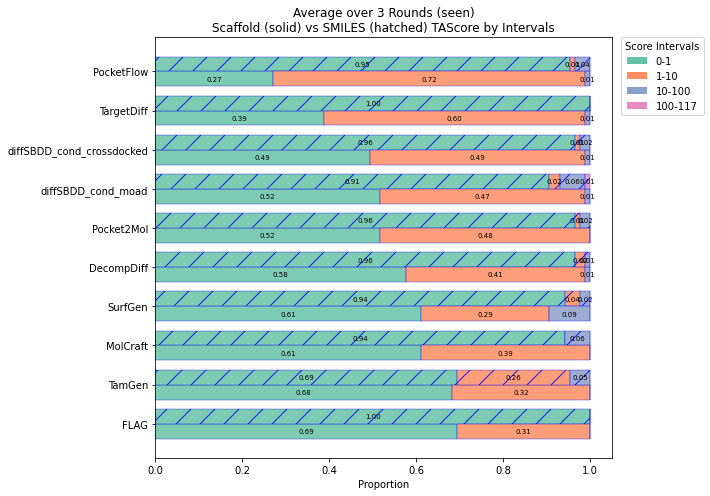

Protein type: seen
Number of targets: 85
Bin edges: [  0.   1.  10. 100. 117.]
Valid cols: ['0-1', '1-10', '10-100', '100-117']
Saved figure to: /home/user-home/fanzhehuan/myprojects/MolGenBench/FigShow_new/final_plot/output/TAScore/target_aware_score_TAScore_seen_protein_proportion_with_legend.svg


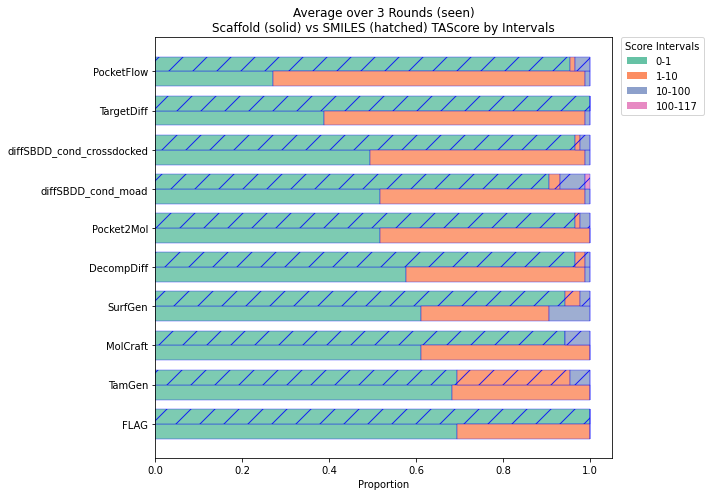

Protein type: unseen
Number of targets: 35
Bin edges: [  0.   1.  10. 100. 105.]
Valid cols: ['0-1', '1-10', '10-100', '100-105']
Saved figure to: /home/user-home/fanzhehuan/myprojects/MolGenBench/FigShow_new/final_plot/output/TAScore/target_aware_score_TAScore_unseen_protein_proportion_with_values_with_legend.svg


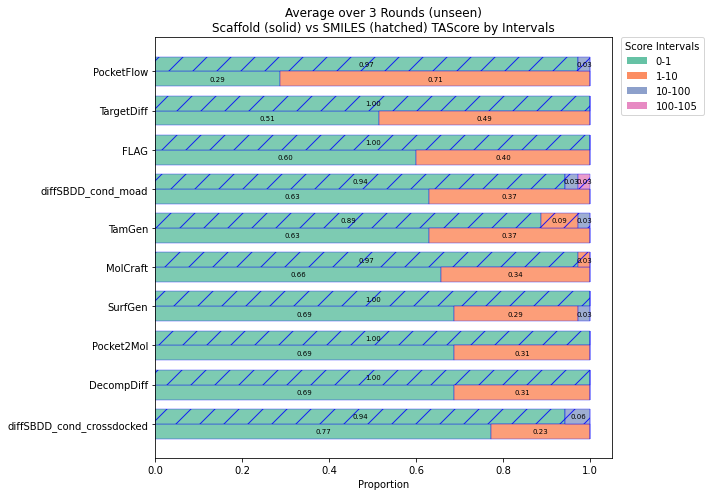

Protein type: unseen
Number of targets: 35
Bin edges: [  0.   1.  10. 100. 105.]
Valid cols: ['0-1', '1-10', '10-100', '100-105']
Saved figure to: /home/user-home/fanzhehuan/myprojects/MolGenBench/FigShow_new/final_plot/output/TAScore/target_aware_score_TAScore_unseen_protein_proportion_with_legend.svg


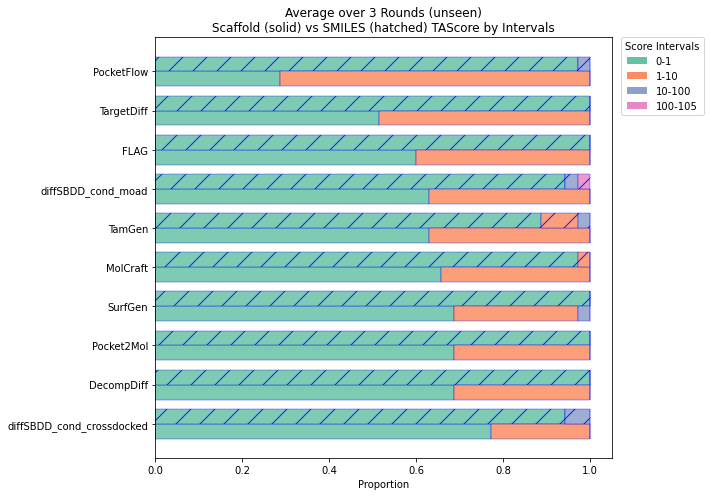

In [7]:
def plot_TAScore_proportion(
    result_df,
    trainset_uniprots=None,
    protein_type='all',
    show_values=True,
    show_legend=True,
    save_dir='.',
    image_name='TAScore'):
    """
    绘制 smiles_TAScore 和 scaffold_TAScore 的分箱堆叠条形图 (Proportion 版本)
    
    Parameters:
    -----------
    result_df : DataFrame with columns: uniprot, ModelName, Round, smiles_TAScore, scaffold_TAScore
    trainset_uniprots : set or dict keys, uniprots in training set (for seen/unseen filtering)
    protein_type : 'all', 'seen', 'unseen'
    show_values : whether to show proportion values on bars
    show_legend : whether to show legend
    save_dir : output directory
    image_name : base name for output file
    """
    
    _df = result_df.copy()
    
    # 过滤 target
    if protein_type == 'all':
        image_name += '_all_protein'
    elif protein_type == 'seen':
        image_name += '_seen_protein'
        if trainset_uniprots is not None:
            _df = _df[_df['uniprot'].isin(trainset_uniprots)]
    elif protein_type == 'unseen':
        image_name += '_unseen_protein'
        if trainset_uniprots is not None:
            _df = _df[~_df['uniprot'].isin(trainset_uniprots)]
    
    print(f'Protein type: {protein_type}')
    print(f'Number of targets: {len(_df["uniprot"].unique())}')
    
    # 按 (ModelName, uniprot) 平均三个 round
    _avg_df = (_df
               .groupby(['ModelName', 'uniprot'])[['scaffold_TAScore', 'smiles_TAScore']]
               .mean()
               .reset_index())
    
    _df_scores = _avg_df[['ModelName', 'uniprot', 'scaffold_TAScore', 'smiles_TAScore']].copy()
    
    # 动态分箱
    _edges_base = [0.0, 1.0, 10.0, 100.0]
    _upper = float(np.nanmax([
        _df_scores['scaffold_TAScore'].max(),
        _df_scores['smiles_TAScore'].max()
    ]))
    if _upper <= _edges_base[-1]:
        _upper = _edges_base[-1] + 1.0
    _upper_int = int(np.ceil(_upper))
    _bin_edges = np.array(_edges_base + [_upper_int], dtype=float)
    valid_cols = [f"{int(_bin_edges[i])}-{int(_bin_edges[i+1])}" for i in range(len(_bin_edges) - 1)]
    
    print('Bin edges:', _bin_edges)
    print('Valid cols:', valid_cols)
    
    # 分箱
    _cats_scf = pd.cut(_df_scores['scaffold_TAScore'],
                       bins=_bin_edges, labels=valid_cols, right=False, include_lowest=True)
    _cats_smi = pd.cut(_df_scores['smiles_TAScore'],
                       bins=_bin_edges, labels=valid_cols, right=False, include_lowest=True)
    
    # 统计计数
    _counts_scf = _df_scores.groupby(['ModelName', _cats_scf]).size().unstack(fill_value=0)
    _counts_smi = _df_scores.groupby(['ModelName', _cats_smi]).size().unstack(fill_value=0)
    
    all_targets_num = len(_avg_df['uniprot'].unique())
    
    # 补全缺失列
    for _lab in valid_cols:
        if _lab not in _counts_scf.columns:
            _counts_scf[_lab] = 0
        if _lab not in _counts_smi.columns:
            _counts_smi[_lab] = 0
    
    # 补充缺失的 target 到 0-1 桶
    if '0-1' in _counts_scf.columns:
        _counts_scf['0-1'] += (all_targets_num - _counts_scf.sum(axis=1)).clip(lower=0)
    if '0-1' in _counts_smi.columns:
        _counts_smi['0-1'] += (all_targets_num - _counts_smi.sum(axis=1)).clip(lower=0)
    
    # 只保留并按列顺序
    _counts_scf = _counts_scf[valid_cols]
    _counts_smi = _counts_smi[valid_cols]
    
    # 归一化为 Proportion
    pivot_scf_prop = _counts_scf.div(_counts_scf.sum(axis=1), axis=0).fillna(0)
    pivot_smi_prop = _counts_smi.div(_counts_smi.sum(axis=1), axis=0).fillna(0)
    
    # 排序依据：Scaffold 的 0-1 bin proportion 降序
    order = pivot_scf_prop.sort_values(by=valid_cols[0], ascending=False).index.tolist()
    pivot_scf_sorted = pivot_scf_prop.loc[order]
    pivot_smi_sorted = pivot_smi_prop.loc[order]
    
    models = order
    n_models = len(models)
    y = np.arange(n_models)
    h = 0.38
    
    colors = sns.color_palette("Set2", n_colors=len(valid_cols))
    fig, ax = plt.subplots(figsize=(10, 0.6 * n_models + 1))
    
    bscf = np.zeros(n_models, dtype=float)
    bsmi = np.zeros(n_models, dtype=float)
    
    # 堆积条形
    for i, lab in enumerate(valid_cols):
        vals_scf = pivot_scf_sorted[lab].values.astype(float)
        vals_smi = pivot_smi_sorted[lab].values.astype(float)
        
        ax.barh(y - h / 2, vals_scf, left=bscf, height=h,
                color=colors[i], alpha=0.85, edgecolor='blue', linewidth=0.4)
        ax.barh(y + h / 2, vals_smi, left=bsmi, height=h,
                color=colors[i], alpha=0.85, hatch='/', edgecolor='blue', linewidth=0.4)
        
        if show_values:
            centers_scf = bscf + vals_scf / 2
            centers_smi = bsmi + vals_smi / 2
            for r_idx, v in enumerate(vals_scf):
                if v > 0.01:  # 只显示大于 1% 的值
                    ax.text(centers_scf[r_idx], y[r_idx] - h / 2, f"{v:.2f}",
                            ha='center', va='center', fontsize=7, color='black')
            for r_idx, v in enumerate(vals_smi):
                if v > 0.01:
                    ax.text(centers_smi[r_idx], y[r_idx] + h / 2, f"{v:.2f}",
                            ha='center', va='center', fontsize=7, color='black')
        
        bscf += vals_scf
        bsmi += vals_smi
    
    ax.set_xlim(0, 1.05)
    ax.set_yticks(y)
    ax.set_yticklabels(models)
    ax.set_xlabel('Proportion')
    ax.set_title(f'Average over 3 Rounds ({protein_type})\nScaffold (solid) vs SMILES (hatched) TAScore by Intervals')
    
    if show_legend:
        interval_handles = [Patch(facecolor=colors[i], label=lab) for i, lab in enumerate(valid_cols)]
        ax.legend(handles=interval_handles, title='Score Intervals',
                  loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0.)
    
    fig.tight_layout()
    
    # 构建文件名后缀
    suffix = '_proportion'
    if show_values:
        suffix += '_with_values'
    if show_legend:
        suffix += '_with_legend'
    if not show_values and not show_legend:
        suffix += '_clean'
    
    out_fig = os.path.join(save_dir, f'target_aware_score_{image_name}{suffix}.svg')
    plt.savefig(out_fig, bbox_inches='tight', dpi=600, format='svg')
    print(f'Saved figure to: {out_fig}')
    
    plt.show()
    
    return pivot_scf_prop, pivot_smi_prop, _df_scores

# 遍历所有蛋白质类型绘制 Proportion 图
for protein_type in ['seen', 'unseen']:
    # 带 legend 和 values
    plot_TAScore_proportion(
        result_df,
        trainset_uniprots=trainset_uniprots,
        protein_type=protein_type,
        show_values=True,
        show_legend=True,
        save_dir=output_path,
        image_name='TAScore'
    )
    
    # 不带 values
    plot_TAScore_proportion(
        result_df,
        trainset_uniprots=trainset_uniprots,
        protein_type=protein_type,
        show_values=False,
        show_legend=True,
        save_dir=output_path,
        image_name='TAScore'
    )